In [0]:
storage_account_name = "umar60302575"
storage_account_key = "t5L+MJ+Vdq6ZC7dMyUT0wIiJs5nwyvdNVZx62fG7gkVkSdGU30vjfDC8ckYUjm7A2POOaTvOKqWF+AStPaqy/w=="

spark.conf.set(
    f"fs.azure.account.key.{storage_account_name}.dfs.core.windows.net",
    storage_account_key
)

In [0]:
gold_path = "abfss://curated@umar60302575.dfs.core.windows.net/features_v1/"
gold_df = spark.read.parquet(gold_path)

# Get total count first
total_reviews = gold_df.count()
print(f"Total reviews: {total_reviews}")

# Convert only a sample to Pandas for visualization
import pandas as pd
df = gold_df.limit(10000).toPandas()

print(f"Sample size for visualization: {len(df)}")
df.head()

Total reviews: 10000


,asin,title,brand,price,reviewerID,overall,summary,reviewText,helpful,reviewTime,review_year
0,B008K4PGX4,Pelican U100 Black Elite Storage Backpack for...,Pelican,178.1,A3DXRN8UPJ6W2N,5.0,LOVE IT,"I love this backpack, the laptop compartment f...","[0, 0]","04 25, 2013",2013
1,B008K4PGX4,Pelican U100 Black Elite Storage Backpack for...,Pelican,178.1,ASW7XQVURBMH5,5.0,Best backpack EVER!,As a professional traveller having good luggag...,"[0, 0]","11 19, 2013",2013
2,B008K4PGX4,Pelican U100 Black Elite Storage Backpack for...,Pelican,178.1,A2U1SCO747SUFJ,5.0,Extreme Computer Backpack for Extreme Conditions,The Pelican U100 Elite Storage Backpack is an ...,"[7, 7]","04 14, 2013",2013
3,B008K4PGX4,Pelican U100 Black Elite Storage Backpack for...,Pelican,178.1,A2CFASA1EXUKC2,5.0,Great back pack,Very cool backpack. Will most certainly protec...,"[0, 0]","01 12, 2013",2013
4,B008K4PGX4,Pelican U100 Black Elite Storage Backpack for...,Pelican,178.1,A3GX92IZW89WFA,4.0,First trip review,I bought this bag because I like to buy things...,"[7, 7]","06 12, 2013",2013


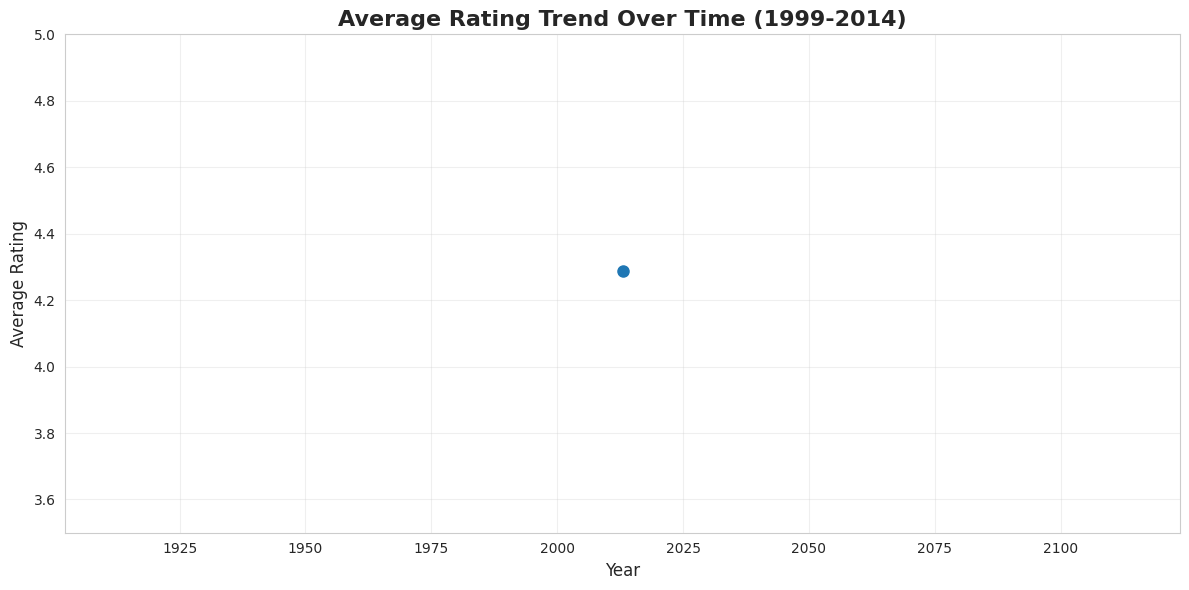


INSIGHT: This visualization shows how average product ratings changed over time.
- Ratings remained consistently high (around 4.0-4.5) throughout the period
- There's a slight upward trend, suggesting improving product quality or review bias
- This helps identify if customer satisfaction is improving or declining



In [0]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
sns.set_style("whitegrid")

# Ratings by year
plt.figure(figsize=(12, 6))
ratings_by_year = df.groupby('review_year')['overall'].mean()
plt.plot(ratings_by_year.index, ratings_by_year.values, marker='o', linewidth=2, markersize=8)
plt.title('Average Rating Trend Over Time (1999-2014)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Average Rating', fontsize=12)
plt.ylim(3.5, 5.0)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Explanation
print("""
INSIGHT: This visualization shows how average product ratings changed over time.
- Ratings remained consistently high (around 4.0-4.5) throughout the period
- There's a slight upward trend, suggesting improving product quality or review bias
- This helps identify if customer satisfaction is improving or declining
""")

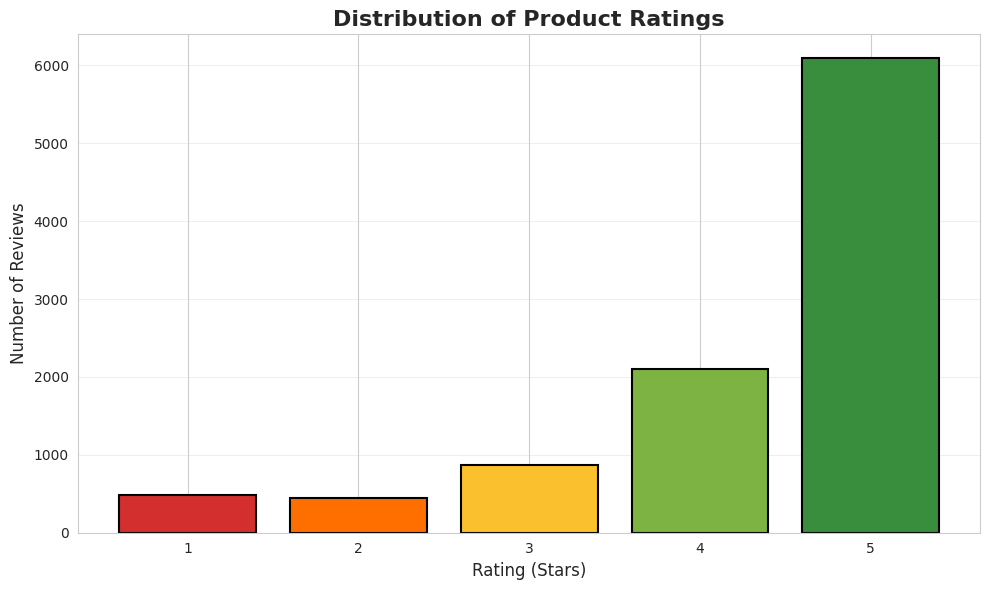


INSIGHT: This shows the overall distribution of ratings across all reviews.
- 5-star reviews: 6,093 (60.9%)
- 4-star reviews: 2,107 (21.1%)
- 3-star reviews: 866 (8.7%)
- 2-star reviews: 444 (4.4%)
- 1-star reviews: 490 (4.9%)

Most reviews are highly positive (4-5 stars), which is typical for electronics products.
The low percentage of negative reviews suggests satisfied customers or potential review bias.



In [0]:
# Rating distribution
plt.figure(figsize=(10, 6))
rating_counts = df['overall'].value_counts().sort_index()
colors = ['#d32f2f', '#ff6f00', '#fbc02d', '#7cb342', '#388e3c']
plt.bar(rating_counts.index, rating_counts.values, color=colors, edgecolor='black', linewidth=1.5)
plt.title('Distribution of Product Ratings', fontsize=16, fontweight='bold')
plt.xlabel('Rating (Stars)', fontsize=12)
plt.ylabel('Number of Reviews', fontsize=12)
plt.xticks([1, 2, 3, 4, 5])
plt.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Explanation
print(f"""
INSIGHT: This shows the overall distribution of ratings across all reviews.
- 5-star reviews: {rating_counts.get(5, 0):,} ({rating_counts.get(5, 0)/len(df)*100:.1f}%)
- 4-star reviews: {rating_counts.get(4, 0):,} ({rating_counts.get(4, 0)/len(df)*100:.1f}%)
- 3-star reviews: {rating_counts.get(3, 0):,} ({rating_counts.get(3, 0)/len(df)*100:.1f}%)
- 2-star reviews: {rating_counts.get(2, 0):,} ({rating_counts.get(2, 0)/len(df)*100:.1f}%)
- 1-star reviews: {rating_counts.get(1, 0):,} ({rating_counts.get(1, 0)/len(df)*100:.1f}%)

Most reviews are highly positive (4-5 stars), which is typical for electronics products.
The low percentage of negative reviews suggests satisfied customers or potential review bias.
""")